# **Instalação e Importação de Bibliotecas, Módulos e Pacotes**

In [79]:
!pip install shap lime -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [80]:
# Importação de todas as bibliotecas que serão utilizadas
import pandas as pd
import numpy as np
import seaborn as sns
import shap
import lime
import json
from openai import OpenAI
from lime import lime_tabular
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# **Leitura do Dataset utilizado para treinar os Modelos**

In [81]:
# Define o dataset que será utilizado, disponível em: https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset/data
df = pd.read_csv("./cybersecurity_intrusion_data.csv")

# **Tratamento dos dados**

In [82]:
print("Dataset (Linhas/Colunas <-> Entradas/Features):", df.shape)
df.head(5)

Dataset (Linhas/Colunas <-> Entradas/Features): (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [83]:
# Verifica se existe (e quantos são) valores nulos em cada features/coluna
df.isnull().sum()

session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

In [84]:
# Remove a coluna session_id
df.drop(columns=["session_id"], inplace=True)

# Remove dados duplicados e linhas com valores faltando
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [85]:
print("Dataset (Linhas/Colunas <-> Entradas/Features):", df.shape)
df.head(5)

Dataset (Linhas/Colunas <-> Entradas/Features): (7571, 10)


,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [86]:
# Codificação para as features/colunas com valores não numéricos
categorical_cols = ['protocol_type', 'encryption_used', 'browser_type']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [87]:
for col in categorical_cols:
    print(f"{col} categories: {df[col].cat.categories.tolist()}")

protocol_type categories: ['ICMP', 'TCP', 'UDP']
encryption_used categories: ['AES', 'DES']
browser_type categories: ['Chrome', 'Edge', 'Firefox', 'Safari', 'Unknown']


In [88]:
for col in categorical_cols:
    df[col] = df[col].cat.codes

In [89]:
df.head(5)

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,1,4,492.983263,1,0.606818,1,1,0,1
1,472,1,3,1557.996461,1,0.301569,0,2,0,0
2,629,1,3,75.044262,1,0.739164,2,0,0,1
3,804,2,4,601.248835,1,0.123267,0,4,0,1
4,453,1,5,532.540888,0,0.054874,1,2,0,0


In [90]:
# Normalização/Transformação do valor númerico da feature/colunas Payload_size
scaler = StandardScaler()
df[['network_packet_size', 'session_duration']] = scaler.fit_transform(df[['network_packet_size', 'session_duration']])

In [91]:
df.head(5)

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,0.501113,1,4,-0.375156,1,0.606818,1,1,0,1
1,-0.138863,1,3,0.973062,1,0.301569,0,2,0,0
2,0.652288,1,3,-0.904232,1,0.739164,2,0,0,1
3,1.534144,2,4,-0.238101,1,0.123267,0,4,0,1
4,-0.234607,1,5,-0.325079,0,0.054874,1,2,0,0


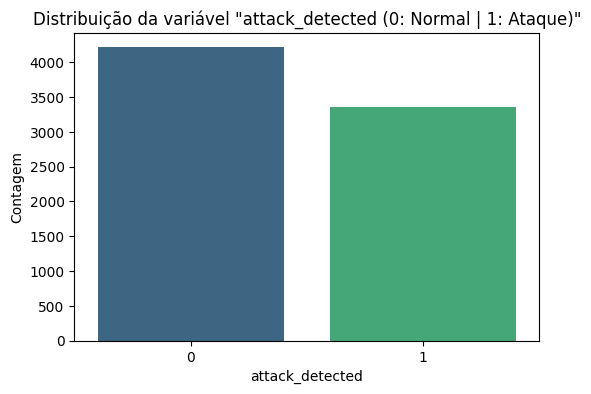

attack_detected
0    0.557
1    0.443
Name: proportion, dtype: float64


In [92]:
# Plota um gráfico de distribuição do Alvo (y) "attack_detected"
plt.figure(figsize=(6, 4))
sns.countplot(x='attack_detected', hue='attack_detected', data=df, palette='viridis', legend=False)
plt.title('Distribuição da variável \"attack_detected (0: Normal | 1: Ataque)\"')
plt.xlabel('attack_detected')
plt.ylabel('Contagem')
plt.show()

print(df['attack_detected'].value_counts(normalize=True).round(3))

In [93]:
# Define as featureas/colunas de treinamento (X) e a feature/coluna de classificação (y)
X = df.drop(['attack_detected'], axis=1)
y = df['attack_detected']

In [94]:
# Particiona o dataset em 70% para treinamento e 30% para teste, use o parâmetro "stratify" para assegurar uma proporção igual da classe "y" ("attack_detected") em cada conjunto (Treinamento e Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [95]:
X_train

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access
6502,0.440643,2,2,0.242475,0,0.057381,0,0,0
3602,2.063258,1,4,2.321934,1,0.470641,1,0,0
8934,0.632131,0,2,-0.634779,0,0.505905,2,0,0
6419,-0.229568,1,5,-0.438799,1,0.086512,2,0,0
2026,1.816338,2,3,-0.116669,0,0.217286,2,1,0
...,...,...,...,...,...,...,...,...,...
3175,-0.758681,1,1,-0.273898,0,0.450046,1,4,0
4205,-0.632702,1,4,-0.681949,1,0.549463,1,0,0
996,1.811299,2,6,-0.768643,0,0.381430,1,1,0
1863,-1.761477,1,4,-0.748356,0,0.131494,0,4,0


In [96]:
y_train

6502    0
3602    0
8934    0
6419    1
2026    0
       ..
3175    0
4205    0
996     0
1863    1
461     0
Name: attack_detected, Length: 5299, dtype: int64

# **Treinamento, Avaliação e Explicabilidade do modelo via SHAP**

In [97]:
# Define a lista de algoritmos de classificação que serão utilizados para treinar o modelo
models = {
    #'Logistic Regression': LogisticRegression(max_iter=1000),
    #'KNN': KNeighborsClassifier(),
    #'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    #'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    #'MLP': MLPClassifier(max_iter=500)
}

In [98]:
# Seleciona uma amostra aleatória do conjunto de teste (X_test), limitada a no máximo 200 linhas para ser utilizado no SHAP
sample_idx = np.random.choice(X_test.index, size=min(200, len(X_test)), replace=False)
X_sample = X_test.loc[sample_idx]

In [99]:
for name, model in models.items():
    print(f"\n🔍 Treinamento do modelo utilizando o algorítmo {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Acurácia: {acc:.4f}")
    print(classification_report(y_test, y_pred))



🔍 Treinamento do modelo utilizando o algorítmo Random Forest...
✅ Acurácia: 0.8948
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1265
           1       1.00      0.77      0.87      1007

    accuracy                           0.89      2272
   macro avg       0.92      0.88      0.89      2272
weighted avg       0.91      0.89      0.89      2272



📊 Explicação SHAP para Random Forest


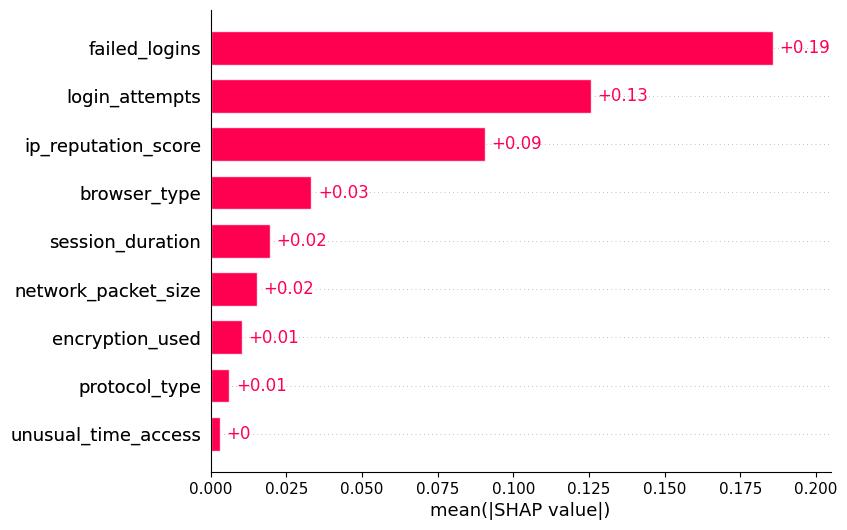

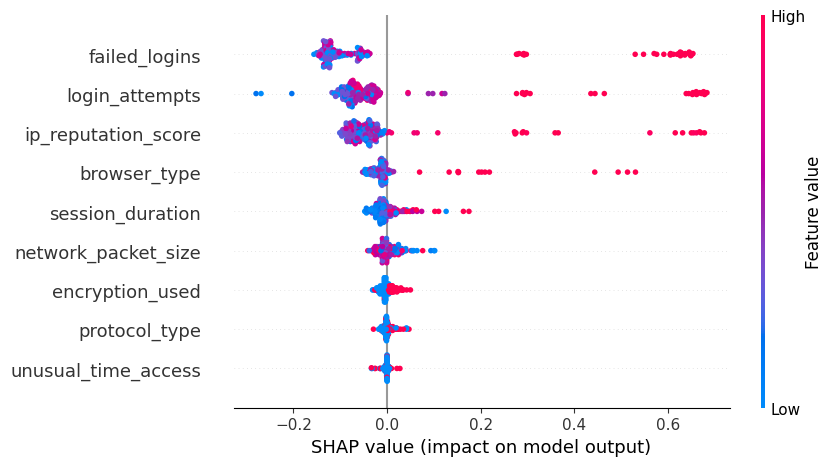

In [100]:
print(f"📊 Explicação SHAP para {name}")

explainer = shap.Explainer(model)
shap_values = explainer(X_sample)
shap.plots.bar(shap_values[...,1])
shap.plots.beeswarm(shap_values[...,1])


# **Explicabilidade do modelo via LIME**

In [101]:
feature_names = ['network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'browser_type', 'unusual_time_access']
class_names = list(y_test.unique())

print(f"📊 Explicação LIME para {name}")

# Cria um objeto do tipo LIME para explicabilidade (Explicabilidade local)
# Para isso o LIME precisa ter acesso aos dados de treinamento e aos nomes das features e alvo
explainer_l = lime_tabular.LimeTabularExplainer(
    X_test.values, # Convert DataFrame to NumPy array
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    verbose=True
)

# Escolhe uma instância qualquer dos dados para gerar a explicabilidade (Ex: 100)
i = 1000
instance_to_explain = X_test.iloc[i].values
# Gera a explicação para a instância escolhida
# A função predict_proba do modelo é passada para o LIME
exp = explainer_l.explain_instance(
    instance_to_explain,
    model.predict_proba,
    #num_features= 6 # Número de features a ser considerada para a explicação
)

# Visualização da explicação via LIME
actual_class_label = y_test.iloc[i]
predicted_class_label = model.predict(instance_to_explain.reshape(1, -1))[0]

print(f"Classificação real: {actual_class_label}")
print(f"Classificação prevista: {predicted_class_label}")

print("\nExplanation details:")
print(exp.as_list())
# exp.show_in_notebook(show_table=True)

📊 Explicação LIME para Random Forest
Intercept 0.6258441729741615
Prediction_local [0.35062309]
Right: 0.98
Classificação real: 1
Classificação prevista: 1

Explanation details:
[('failed_logins <= 1.00', -0.19744257767779316), ('browser_type > 2.00', 0.10998614118030466), ('3.00 < login_attempts <= 4.00', -0.09608567055632045), ('0.19 < ip_reputation_score <= 0.31', -0.0930318430236277), ('session_duration > 0.39', 0.0650747955380842), ('protocol_type <= 1.00', -0.02161349390673972), ('-0.71 < network_packet_size <= -0.02', -0.020273538260365688), ('encryption_used <= 0.00', -0.013010815566657011), ('unusual_time_access <= 0.00', -0.008824075711224207)]


/home/beloin/Documents/pos-grad/masters/soc_xai/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/beloin/Documents/pos-grad/masters/soc_xai/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# **Explicabilidade do modelo via LLM (GPT-5)**

In [ ]:
# Informa a chave da API da OpenAI
client = OpenAI(api_key="")
client = OpenAI(
    base_url="http://localhost:11434/v1",
    timeout=None 
)



In [103]:
# ==========================
# DESCRIÇÃO DAS COLUNAS
# ==========================
column_description = {
    "network_packet_size":"Tamanho do pacote (informação útil)",
    "protocol_type":"Protoloco utilizado, segundo o modelo OSI, podendo ser: TCP, UDP ou ICMP",
    "login_attempts":"Total de tentativas de login realizadas",
    "session_duration":"Duração da sessão",
    "encryption_used":"Criptografia utilizada",
    "ip_reputation_score":"Pontuação referente a reputação do IP da solicitação",
    "failed_logins":"Quantidade de logins que falharam",
    "browser_type":"Tipo de navegador utilizado",
    "unusual_time_access":"Indica se o acesso ocorreu em um horário incomum para o usuário/sistema: sim (1) ou não (0)",
    "attack_detected": "Classificação da comunicação, podendo ser: normal (0) ou ataque (1)"
}

# ==========================
# EQUIVALÊNCIA CATEGORIA -> CÓDIGO NUMÉRICO DAS COLUNAS
# ==========================
category_encoding = {
    "protocol_type": {
        "ICMP":0,
        "TCP":1,
        "UDP":2
    },
    "encryption_used":{
        "AES":0,
        "DES":1
    },
    "browser_type":{
        "Chrome":0,
        "Edge":1,
        "Firefox":2,
        "Safari":3,
        "Unknown":4
    },
    "attack_detected":{
        0:"Normal",
        1:"Ataque"
    }
  }

# Estatísticas do Dataset
stats = df.describe(include="all").to_string()

# Amostra dos dados de treinamento
train_sample = X_train.sample(50)
train_sample["attack_detected"] = y_train.loc[train_sample.index]
train_sample_json = train_sample.to_json(orient="records")

# Amostra das previsões vs real
pred_sample = pd.DataFrame({
    "real": y_test,
    "predicted": y_pred
})

pred_sample_json = pred_sample.sample(50).to_json(orient="records")

# ==========================
# INFORMAÇÕES DO MODELO
# ==========================
model_info = {
    "model_type": "Random Forest",
    "task": "Detecção de intrusão a partir de log. Cada entrada do log é classificada como: Normal (0) ou Ataque (1)",
    "target_variable": "attack_detected",
    "features": list(X.columns)
}

In [104]:
# ==========================
# PROMPT PARA O LLM
# ==========================
prompt = f"""
Você é especialista em Inteligência Artificial Explicável (XAI) e Segurança Cibernética.
Sua tarefa é analisar um modelo de aprendizado de máquina treinado e fornecer uma explicação detalhada de seu comportamento.

=========================
INFORMAÇÕES DO MODELO
=========================
{model_info}

=========================
DESCRIÇÃO DAS COLUNAS
=========================
{column_description}

=========================
CODIFICAÇÃO: CATEGORIA → VALOR NUMÉRICO
=========================
{category_encoding}

=========================
ESTATÍTISCA DO DATASET
=========================
{stats}

=========================
AMOSTRA DOS DADOS DE TREINAMENTO
=========================
{train_sample_json}

=========================
AMOSTRA DA CLASSIFICAÇÃO REAL vs CLASSIFICAÇÃO DO MODELO
=========================
{pred_sample_json}

=========================
TAREFA
=========================

Forneça uma análise detalhada da explicabilidade do modelo, incluindo:

1. Interpretação global e local do comportamento do modelo.
2. Quais características parecem ser mais influentes na previsão de classificação attack_detected: Normal (0) ou Ataque (1)
3. Identifique possíveis padrões ou correlações no conjunto de dados.
4. Analise a amostra de previsão e comente sobre possíveis classificações incorretas.
5. Explique como as codificações categóricas podem influenciar o comportamento do modelo.
6. Forneça insights de segurança cibernética com base nos padrões detectados nos logs.
7. Sugira possíveis melhorias para o modelo ou conjunto de dados.

Sua explicação deve ser técnica, porém clara, estruturada em seções e adequada para um relatório de aprendizado de máquina.
"""

In [105]:
print(prompt)


Você é especialista em Inteligência Artificial Explicável (XAI) e Segurança Cibernética.
Sua tarefa é analisar um modelo de aprendizado de máquina treinado e fornecer uma explicação detalhada de seu comportamento.

INFORMAÇÕES DO MODELO
{'model_type': 'Random Forest', 'task': 'Detecção de intrusão a partir de log. Cada entrada do log é classificada como: Normal (0) ou Ataque (1)', 'target_variable': 'attack_detected', 'features': ['network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'browser_type', 'unusual_time_access']}

DESCRIÇÃO DAS COLUNAS
{'network_packet_size': 'Tamanho do pacote (informação útil)', 'protocol_type': 'Protoloco utilizado, segundo o modelo OSI, podendo ser: TCP, UDP ou ICMP', 'login_attempts': 'Total de tentativas de login realizadas', 'session_duration': 'Duração da sessão', 'encryption_used': 'Criptografia utilizada', 'ip_reputation_score': 'Pontuação referente a reputação do IP

In [106]:
# ==========================
# CHAMADA DA API
# ==========================
response = client.responses.create(
    model="qwen3.5:cloud",
    input=[
        {
            "role": "system",
            "content": "Você é um especialista em Machine Learning e Explainable AI."
        },
        {
            "role": "user",
            "content": prompt
        }
    ],
    max_output_tokens=10000
)

APITimeoutError: Request timed out.

In [ ]:
# ==========================
# RESULTADO
# ==========================

explanation = ""

for item in response.output:
    if item.type == "message":
        for content in item.content:
            if content.type == "output_text":
                explanation += content.text


print("\n===== EXPLICAÇÃO DO MODELO =====\n")
print(explanation)


===== EXPLICAÇÃO DO MODELO =====

A seguir apresento uma análise explicável do modelo Random Forest para detecção de intrusão em logs, estruturada para leitura técnica e ação operacional.

Resumo do contexto
- Tarefa: Classificação binária por entrada de log: Normal (0) vs Ataque (1).
- Modelo: Random Forest.
- Variáveis: numéricas contínuas (ex.: network_packet_size, session_duration, ip_reputation_score) e categóricas codificadas como inteiros (protocol_type, encryption_used, browser_type), além de contagens (login_attempts, failed_logins) e um sinal binário (unusual_time_access).
- Dataset: proporcionalmente balanceado (média de attack_detected ≈ 0.443).
- Codificações categóricas: mapeamentos ordinais simples (ex.: protocol_type ICMP=0, TCP=1, UDP=2).

1) Interpretação do comportamento do modelo
1.1 Interpretação Global (como o modelo geralmente decide)
Com base no domínio, nos padrões observados na amostra e no comportamento típico de Random Forest em dados de segurança, os princ